In [29]:
# ===================================================
# PARTE 0: Instalación y librerías
# ===================================================
library(readr);
library(dplyr);
library(tidyr);
library(skimr);
library(moments);
library(fitdistrplus);
library(ggplot2);
library(scales);
library(purrr);
library(tibble);
library(cluster)

In [30]:
# ===================================================
# PARTE 1: Carga y clasificación de variables
# ===================================================

#Cargue del dataset
kaggle_url <- 'https://www.kaggle.com/datasets/nalisha/mall-customer-segmentation-dataset-for-behavioral'
mirror_url <- 'https://gitee.com/dtval/data/raw/master/Mall_Customers.csv'

# Cargue el dataset directamente desde la URL espejo para reproducibilidad.
datos_raw <- read_csv(mirror_url, show_col_types = FALSE)

datos <- datos_raw %>%
  rename(
    CustomerID = CustomerID,
    Gender = Gender,
    Age = Age,
    Annual_Income = `Annual Income (k$)`,
    Spending_Score = `Spending Score (1-100)`
  ) %>%
  mutate(
    Gender = factor(Gender),
    cliente_alto_gasto = if_else(Spending_Score >= 70, 1, 0),
    ingreso_alto = if_else(Annual_Income >= 70, 1, 0),
    cliente_joven = if_else(Age <= 35, 1, 0)
  )

# Vista general
glimpse(datos)
skim(datos)

# Conteo de valores faltantes por variable
colSums(is.na(datos))

# Tabla de clasificación manual (ajuste según su dataset)
clasificacion <- data.frame(
  Variable = c('CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score'),
  Tipo = c('Identificador', 'Cualitativa nominal', 'Cuantitativa discreta', 'Cuantitativa continua', 'Cuantitativa discreta / ordinal operativa'),
  Escala = c('Nominal', 'Nominal', 'Razon', 'Razon', 'Intervalo'),
  Relevancia_negocio = c(
    'Permite trazabilidad; no debe usarse para inferir comportamiento.',
    'Apoya segmentacion demografica y comparacion de patrones.',
    'Permite identificar grupos etarios y disenar experiencias por ciclo de vida.',
    'Aproxima capacidad de compra anual del cliente.',
    'Resume intensidad o propension de gasto; variable clave para segmentacion.'
  ),
  stringsAsFactors = FALSE
)
print(clasificacion)

Rows: 200
Columns: 8
$ CustomerID         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, …
$ Gender             <fct> Male, Male, Female, Female, Female, Female, Female,…
$ Age                <dbl> 19, 21, 20, 23, 31, 22, 35, 23, 64, 30, 67, 35, 58,…
$ Annual_Income      <dbl> 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 19, 20,…
$ Spending_Score     <dbl> 39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15, 77…
$ cliente_alto_gasto <dbl> 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, …
$ ingreso_alto       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ cliente_joven      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, …


,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,Gender,0,1,FALSE,2,"Fem: 112, Mal: 88",NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,CustomerID,0,1,NA,NA,NA,100.50,57.8791845,1,50.75,100.5,150.25,200,▇▇▇▇▇
3,numeric,Age,0,1,NA,NA,NA,38.85,13.9690073,18,28.75,36.0,49.00,70,▆▇▅▃▂
4,numeric,Annual_Income,0,1,NA,NA,NA,60.56,26.2647212,15,41.50,61.5,78.00,137,▆▇▇▂▁
5,numeric,Spending_Score,0,1,NA,NA,NA,50.20,25.8235217,1,34.75,50.0,73.00,99,▃▃▇▃▃
6,numeric,cliente_alto_gasto,0,1,NA,NA,NA,0.27,0.4450735,0,0.00,0.0,1.00,1,▇▁▁▁▃
7,numeric,ingreso_alto,0,1,NA,NA,NA,0.38,0.4866045,0,0.00,0.0,1.00,1,▇▁▁▁▅
8,numeric,cliente_joven,0,1,NA,NA,NA,0.49,0.5011544,0,0.00,0.0,1.00,1,▇▁▁▁▇


CustomerID             Gender                Age      Annual_Income 
                 0                  0                  0                  0 
    Spending_Score cliente_alto_gasto       ingreso_alto      cliente_joven 
                 0                  0                  0                  0

        Variable                                      Tipo    Escala
1     CustomerID                             Identificador   Nominal
2         Gender                       Cualitativa nominal   Nominal
3            Age                     Cuantitativa discreta     Razon
4  Annual_Income                     Cuantitativa continua     Razon
5 Spending_Score Cuantitativa discreta / ordinal operativa Intervalo
                                                            Relevancia_negocio
1            Permite trazabilidad; no debe usarse para inferir comportamiento.
2                    Apoya segmentacion demografica y comparacion de patrones.
3 Permite identificar grupos etarios y disenar experiencias por ciclo de vida.
4                              Aproxima capacidad de compra anual del cliente.
5   Resume intensidad o propension de gasto; variable clave para segmentacion.


# A tibble: 3 × 11
  Variable       Media Mediana  Moda    SD Varianza   IQR   Min   Max Skewness
  <chr>          <dbl>   <dbl> <dbl> <dbl>    <dbl> <dbl> <dbl> <dbl>    <dbl>
1 Age             38.8    36      32  14.0     195.  20.2    18    70   0.482 
2 Annual_Income   60.6    61.5    54  26.3     690.  36.5    15   137   0.319 
3 Spending_Score  50.2    50      42  25.8     667.  38.2     1    99  -0.0469
# ℹ 1 more variable: Kurtosis <dbl>

--- Estadísticas detalladas para Spending_Score ---
Media:  50.2 
Mediana:  50 
SD:  25.82352 
IQR:  38.25 
Skewness:  -0.04686531 
Kurtosis:  2.164042 

--- Summary de Spending_Score ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   34.75   50.00   50.20   73.00   99.00 


--- Ajuste a distribucion Normal para Spending_Score ---


Fitting of the distribution ' norm ' by maximum likelihood 
Parameters : 
     estimate Std. Error
mean 50.20000   1.821428
sd   25.75888   1.287944
Loglikelihood:  -933.5436   AIC:  1871.087   BIC:  1877.684 
Correlation matrix:
     mean sd
mean    1  0
sd      0  1


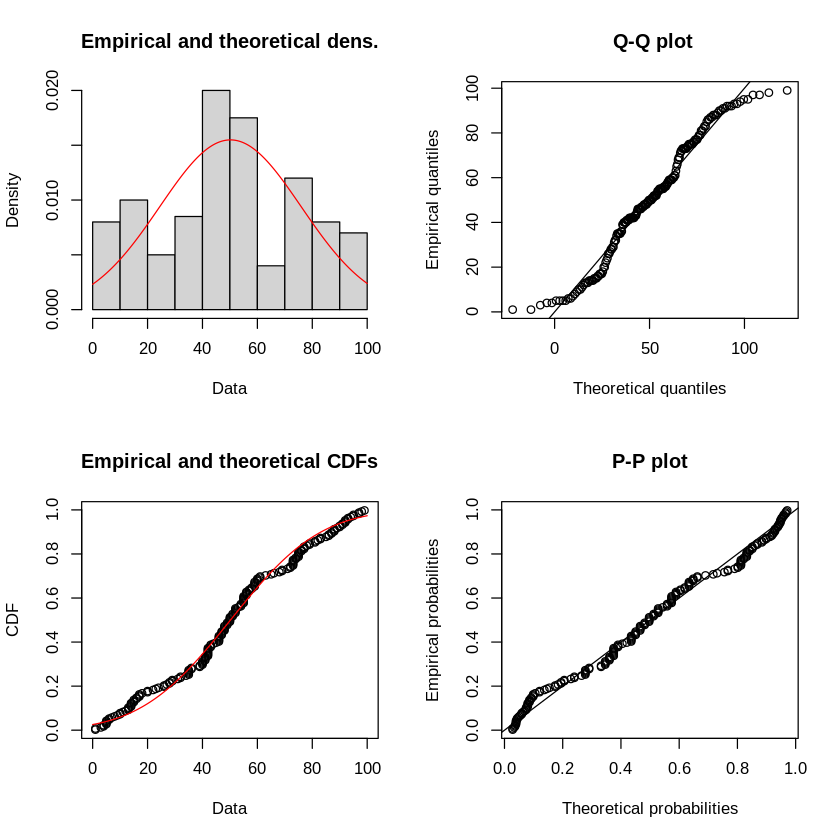


--- Probabilidades condicionales (Gender vs cliente_alto_gasto) ---

Tabla de contingencia:
        
          0  1
  Female 80 32
  Male   66 22

Probabilidades conjuntas:
        
            0    1
  Female 0.40 0.16
  Male   0.33 0.11

Probabilidades condicionales por fila (Gender dado cliente_alto_gasto):
        
                 0         1
  Female 0.7142857 0.2857143
  Male   0.7500000 0.2500000


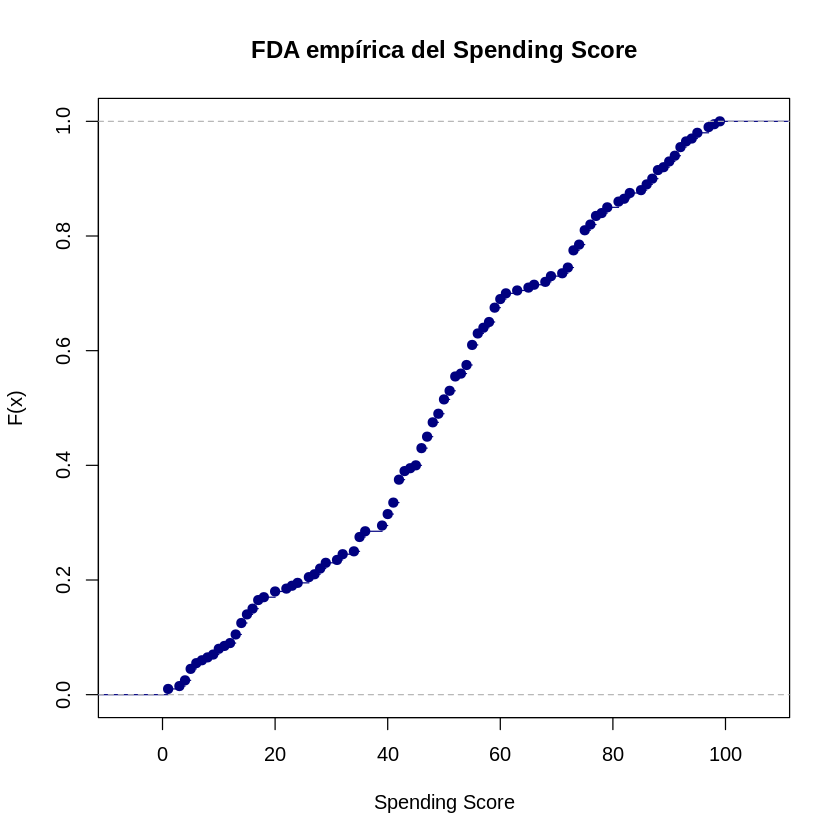

In [31]:
# ===================================================
# PARTE 2: Estadísticas descriptivas y distribuciones
# ===================================================
moda <- function(x) { x <- x[!is.na(x)]; ux <- unique(x); ux[which.max(tabulate(match(x, ux)))] }
vars_numericas <- c('Age','Annual_Income','Spending_Score')

# Resumen de estadísticas para variables numéricas
resumen_num <- map_dfr(vars_numericas, function(v) {
  x <- datos[[v]]
  tibble(Variable=v, Media=mean(x), Mediana=median(x), Moda=moda(x), SD=sd(x), Varianza=var(x), IQR=IQR(x), Min=min(x), Max=max(x), Skewness=skewness(x), Kurtosis=kurtosis(x))
})
print(resumen_num)

# Estadísticas detalladas para Spending_Score
cat('\n--- Estadísticas detalladas para Spending_Score ---\n')
var_objetivo <- datos$Spending_Score
cat('Media: ', mean(var_objetivo, na.rm = TRUE), '\n')
cat('Mediana: ', median(var_objetivo, na.rm = TRUE), '\n')
cat('SD: ', sd(var_objetivo, na.rm = TRUE), '\n')
cat('IQR: ', IQR(var_objetivo, na.rm = TRUE), '\n')
cat('Skewness: ', moments::skewness(var_objetivo, na.rm = TRUE), '\n')
cat('Kurtosis: ', moments::kurtosis(var_objetivo, na.rm = TRUE), '\n')

# Resumen completo
cat('\n--- Summary de Spending_Score ---\n')
summary(var_objetivo)

# Ajuste a distribución teórica (ejemplo: normal)
cat('\n--- Ajuste a distribucion Normal para Spending_Score ---\n')
fit_norm_score <- fitdist(datos$Spending_Score, 'norm')
summary(fit_norm_score)
plot(fit_norm_score)

# FDA empírica para Spending_Score
plot(ecdf(datos$Spending_Score), main = 'FDA empírica del Spending Score', col = 'navy', xlab = 'Spending Score', ylab = 'F(x)')

# Probabilidades condicionales (tabla de contingencia) Gender vs cliente_alto_gasto
cat('\n--- Probabilidades condicionales (Gender vs cliente_alto_gasto) ---\n')
tabla_contingencia <- table(datos$Gender, datos$cliente_alto_gasto)
cat('\nTabla de contingencia:\n')
print(tabla_contingencia)

cat('\nProbabilidades conjuntas:\n')
print(prop.table(tabla_contingencia))

cat('\nProbabilidades condicionales por fila (Gender dado cliente_alto_gasto):\n')
print(prop.table(tabla_contingencia, margin = 1))


$P_cliente_alto_gasto
[1] 0.27

$P_ingreso_alto
[1] 0.38

$P_alto_gasto_dado_ingreso_alto
[1] 0.4473684

$P_alto_gasto_dado_cliente_joven
[1] 0.4489796

$P_alto_gasto_e_ingreso_alto
[1] 0.17

$Esperanza_Spending_Score
[1] 50.2

        
            0    1
  Female 0.40 0.16
  Male   0.33 0.11

        
                 0         1
  Female 0.7142857 0.2857143
  Male   0.7500000 0.2500000

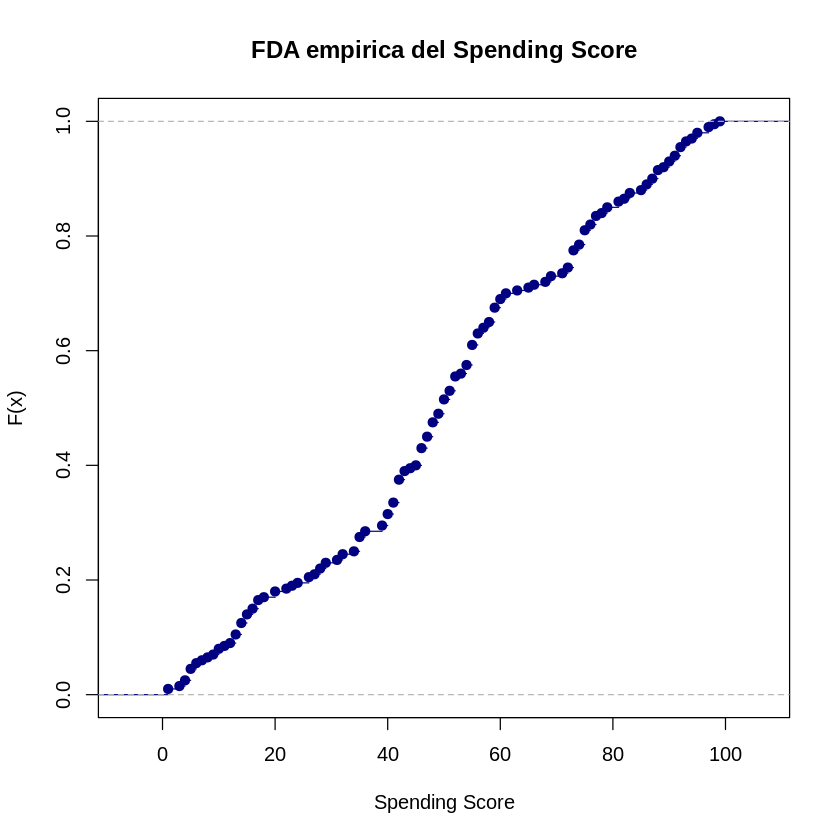

In [32]:
# Probabilidades simples, conjuntas y condicionales
prob_alto_gasto <- mean(datos$cliente_alto_gasto)
prob_ingreso_alto <- mean(datos$ingreso_alto)
prob_alto_gasto_dado_ingreso_alto <- datos %>% filter(ingreso_alto == 1) %>% summarise(p = mean(cliente_alto_gasto))
prob_alto_gasto_dado_joven <- datos %>% filter(cliente_joven == 1) %>% summarise(p = mean(cliente_alto_gasto))
prob_conjunta <- mean(datos$cliente_alto_gasto == 1 & datos$ingreso_alto == 1)

list(
  P_cliente_alto_gasto = prob_alto_gasto,
  P_ingreso_alto = prob_ingreso_alto,
  P_alto_gasto_dado_ingreso_alto = prob_alto_gasto_dado_ingreso_alto$p,
  P_alto_gasto_dado_cliente_joven = prob_alto_gasto_dado_joven$p,
  P_alto_gasto_e_ingreso_alto = prob_conjunta,
  Esperanza_Spending_Score = mean(datos$Spending_Score)
)

plot(ecdf(datos$Spending_Score), main = 'FDA empirica del Spending Score', xlab = 'Spending Score', ylab = 'F(x)', col = 'navy')
tabla <- table(datos$Gender, datos$cliente_alto_gasto)
prop.table(tabla)
prop.table(tabla, margin = 1)

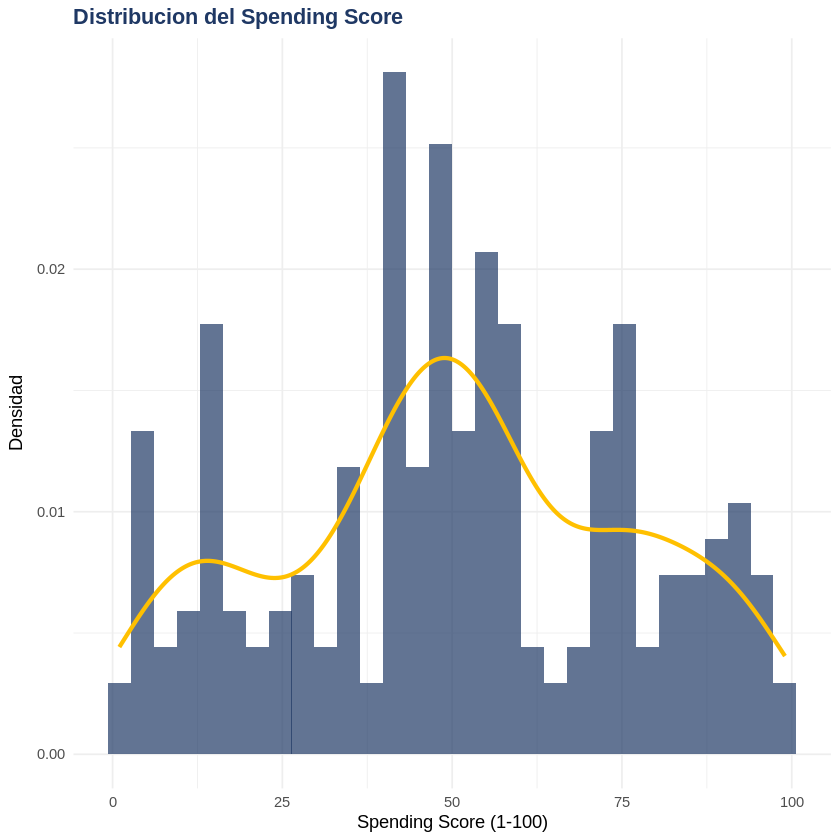

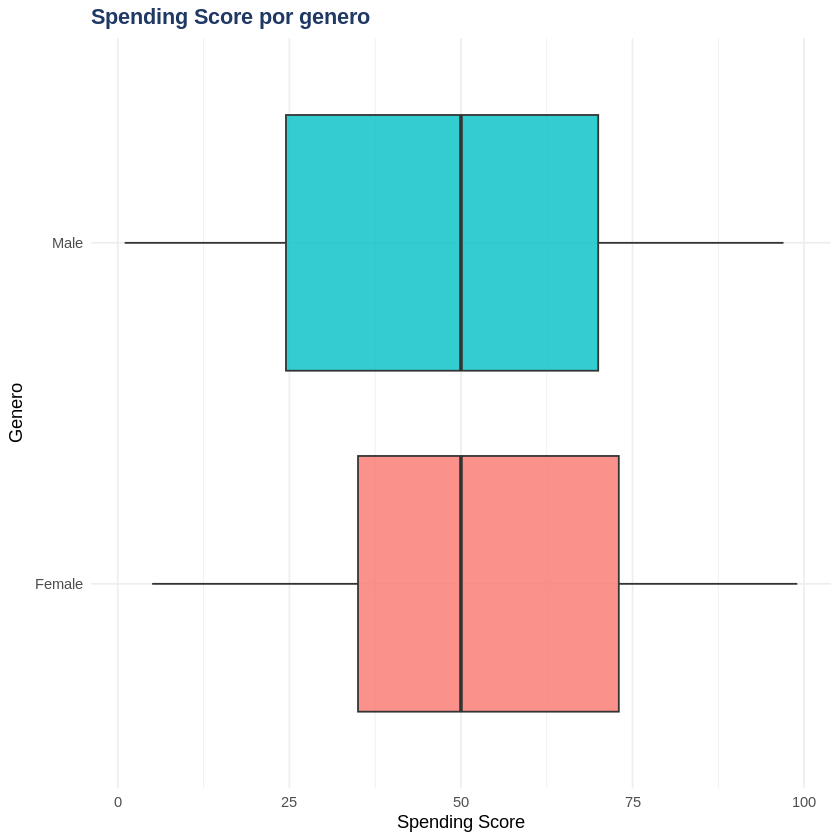

`geom_smooth()` using formula = 'y ~ x'


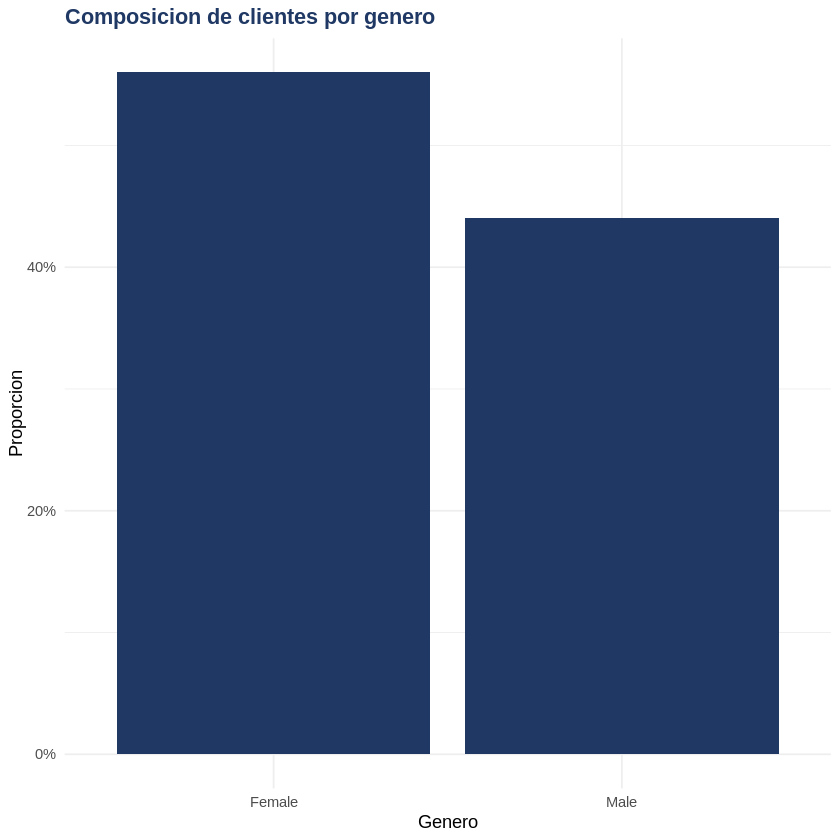

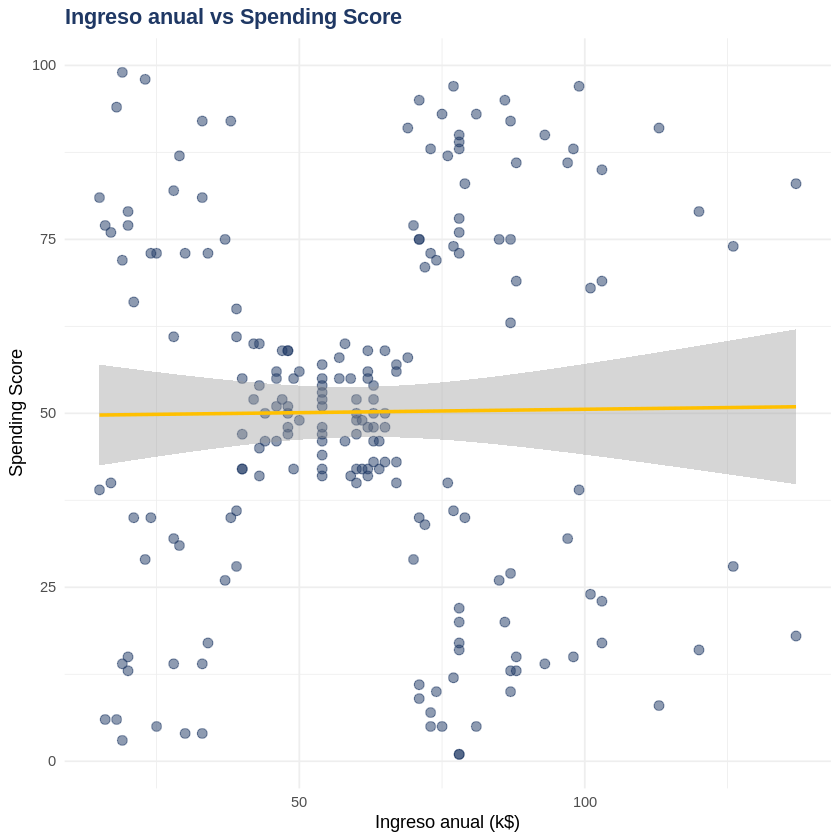

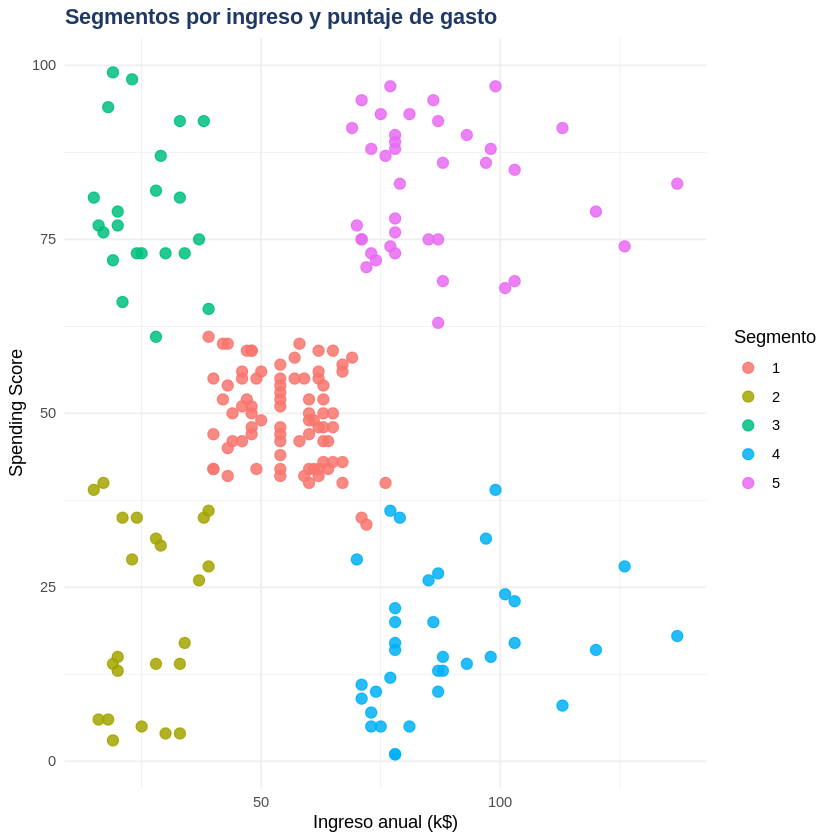

In [33]:
# ===================================================
# PARTE 3: Visualización exploratoria con ggplot2
# ===================================================
mi_tema <- theme_minimal() + theme(plot.title=element_text(face='bold', color='#1F3864', size=13), axis.title=element_text(size=11), panel.grid=element_line(color='#EEEEEE'))

# 1. Histograma + KDE
ggplot(datos, aes(x=Spending_Score)) + geom_histogram(aes(y=after_stat(density)), bins=30, fill='#1F3864', alpha=0.7) + geom_density(color='#FFC000', linewidth=1.2) + labs(title='Distribucion del Spending Score', x='Spending Score (1-100)', y='Densidad') + mi_tema

# 2. Boxplot por categoria
ggplot(datos, aes(x=reorder(Gender, Spending_Score, median), y=Spending_Score, fill=Gender)) + geom_boxplot(alpha=0.8, outlier.color='red', outlier.size=2) + coord_flip() + labs(title='Spending Score por genero', x='Genero', y='Spending Score') + mi_tema + theme(legend.position='none')

# 3. Barras
datos %>% count(Gender) %>% mutate(prop=n/sum(n)) %>% ggplot(aes(x=reorder(Gender, -prop), y=prop)) + geom_col(fill='#1F3864') + scale_y_continuous(labels=scales::percent) + labs(title='Composicion de clientes por genero', x='Genero', y='Proporcion') + mi_tema

# 4. Scatter plot
ggplot(datos, aes(x=Annual_Income, y=Spending_Score)) + geom_point(alpha=0.5, color='#1F3864', size=2.4) + geom_smooth(method='lm', se=TRUE, color='#FFC000') + labs(title='Ingreso anual vs Spending Score', x='Ingreso anual (k$)', y='Spending Score') + mi_tema

# 5. Grafica libre: clusters comerciales
set.seed(123)
segmentos <- datos %>% dplyr::select(Annual_Income, Spending_Score) %>% scale() %>% kmeans(centers = 5, nstart = 25)
datos_cluster <- datos %>% mutate(segmento = factor(segmentos$cluster))
ggplot(datos_cluster, aes(x=Annual_Income, y=Spending_Score, color=segmento)) + geom_point(size=2.8, alpha=0.85) + labs(title='Segmentos por ingreso y puntaje de gasto', x='Ingreso anual (k$)', y='Spending Score', color='Segmento') + mi_tema

Exitos: 54 / Total: 200 / Proporcion: 0.27 
A priori: Beta( 3 , 7 )
A posteriori: Beta( 57 , 153 )
Media a priori:  0.3 
Media a posteriori: 0.271 
IC 90%: [ 0.222 , 0.323 ]


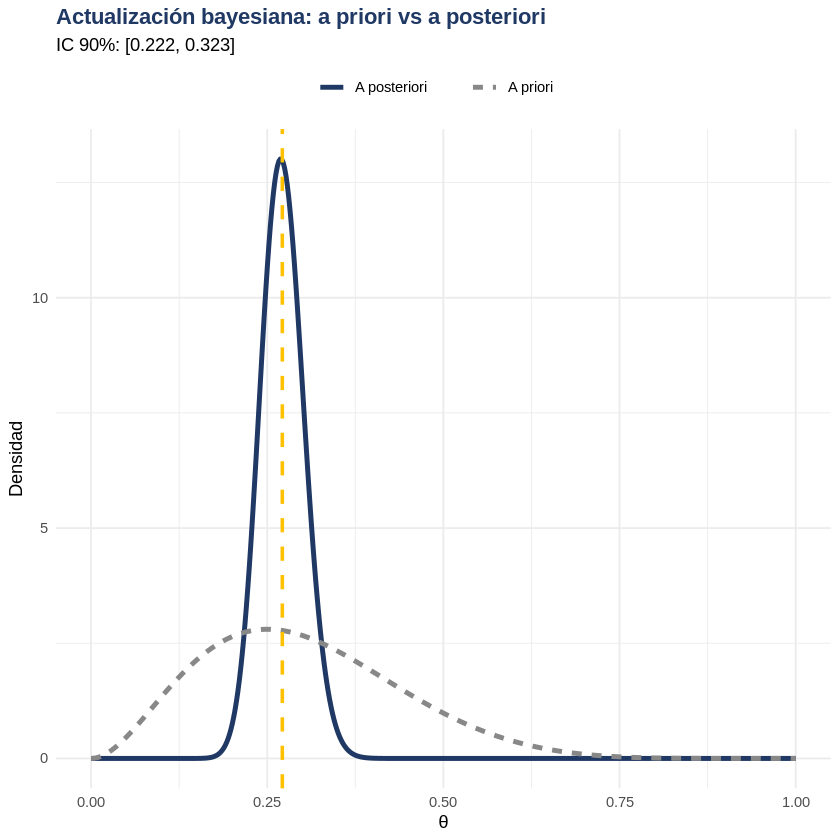

In [34]:
# ===================================================
# PARTE 4: Inferencia Bayesiana (Beta-Binomial)
# ===================================================

# --- 1. Definir parámetros ---
# Evento de interes: cliente de alto potencial comercial (Spending Score >= 70)
alpha_prior <- 3 # creencia previa de éxitos
beta_prior <- 7 # creencia previa de fracasos

# Evidencia de los datos
k <- sum(datos$cliente_alto_gasto == 1) # éxitos observados
n <- nrow(datos) # total de observaciones
cat('Exitos:', k, '/ Total:', n, '/ Proporcion:', round(k/n, 3), '\n')

# --- 2. Distribución a posteriori ---
alpha_post <- alpha_prior + k
beta_post <- beta_prior + (n - k)

cat('A priori: Beta(', alpha_prior, ',', beta_prior, ')\n')
cat('A posteriori: Beta(', alpha_post, ',', beta_post, ')\n')
cat('Media a priori: ', round(alpha_prior/(alpha_prior+beta_prior), 3), '\n')
cat('Media a posteriori:', round(alpha_post/(alpha_post+beta_post), 3), '\n')

# --- 3. Intervalo de credibilidad 90% ---
ic_90 <- qbeta(c(0.05, 0.95), alpha_post, beta_post)
cat('IC 90%: [', round(ic_90[1], 3), ',', round(ic_90[2], 3), ']\n')

# --- 4. Gráfica: a priori vs a posteriori ---
theta <- seq(0, 1, length.out = 500)
df_plot <- data.frame(
  theta = rep(theta, 2),
  densidad = c(dbeta(theta, alpha_prior, beta_prior), dbeta(theta, alpha_post, beta_post)),
  distribucion = rep(c('A priori','A posteriori'), each=500)
)
ggplot(df_plot, aes(x=theta, y=densidad, color=distribucion, linetype=distribucion)) +
  geom_line(linewidth=1.4) +
  scale_color_manual(values=c('A priori'='#888888','A posteriori'='#1F3864')) +
  geom_vline(xintercept=alpha_post/(alpha_post+beta_post), color='#FFC000', linetype='dashed', linewidth=1) +
  labs(title='Actualización bayesiana: a priori vs a posteriori', subtitle=paste0('IC 90%: [', round(ic_90[1],3), ', ', round(ic_90[2],3), ']'), x=expression(theta), y='Densidad', color='', linetype='') +
  theme_minimal() +
  theme(legend.position='top', plot.title=element_text(face='bold', color='#1F3864'))